

# 1. Definición de Constantes Físicas
e = 1.602176634e-19       # Carga elemental (C)
g = 9.806                 # Gravedad (m/s^2)
eta = 1.81e-5             # Viscosidad del aire (kg/(m*s))
delta = 1050.0            # Densidad del latex (kg/m^3)
rho_air = 0.88            # Densidad del aire en Quito (kg/m^3)
D = 1.02e-6               # Diámetro de la gota (m)
R = D / 2                 # Radio de la gota (m)
d_placas = 0.005          # Separación entre placas (m)
dy = 0.002                # Distancia de medición (2 mm)

# 2. Términos pre-calculados para eficiencia
Volumen = (4/3) * np.pi * R**3
Peso_efectivo = (delta - rho_air) * Volumen * g
Constante_viscosa = 6 * np.pi * eta * R * dy

# Parámetros del experimento
N_datos = 300
voltaje_aplicado = 200.0  # [V]

# 3. Generación del vector de "Realidad Cuantizada"
# Asignamos aleatoriamente entre 4 y 15 electrones a las gotas (rango que da tiempos medibles)
n_electrones = np.random.randint(6, 17, N_datos)

# 4. Cálculo determinista del tiempo basado en la física
tiempos_teoricos = np.zeros(N_datos)
Fuerza_electrica = n_electrones * e * (voltaje_aplicado / d_placas)

# Denominador de nuestra ecuación deducida
Fuerza_neta_ascendente = Fuerza_electrica - Peso_efectivo

# Calculamos t y verificamos que la fuerza neta sea positiva (que la gota suba)
for i in range(N_datos):
    if Fuerza_neta_ascendente[i] > 0:
        tiempos_teoricos[i] = Constante_viscosa / Fuerza_neta_ascendente[i]
    else:
        tiempos_teoricos[i] = np.nan # Gota que cae, no nos sirve para esta medición

# 5. Inyección de error experimental (El Cronómetro)
# Asumimos un error de reacción humana de +/- 0.15 segundos
error_cronometro = np.random.normal(loc=0.0, scale=0.15, size=N_datos)
tiempos_medidos = tiempos_teoricos + error_cronometro

# 6. Estructuración y exportación de la tabla
df_laboratorio = pd.DataFrame({
    'Voltaje [V]': np.full(N_datos, voltaje_aplicado),
    'Distancia [mm]': np.full(N_datos, dy * 1000),
    'Tiempo [s]': np.round(tiempos_medidos, 2),
    'Electrones_Ocultos (Solo para validación)': n_electrones
})

# Guardar la tabla en formato CSV para importarla a Excel
df_laboratorio.to_csv('datos_simulados_millikan.csv', index=False)

print("Muestra de los primeros 10 datos generados:")
print(df_laboratorio.head(10))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

In [2]:
archivo = pd.read_excel('LAB4DAVID.xlsx', sheet_name='Hoja 1')
df = pd.DataFrame(archivo)

df

,#,"Voltaje [V] para todas las mediciones, alrededor de 200 V, varia de 199 a 201 maso",Distancia [mm],Tiempo [s],Unnamed: 4,Incertidumbres,Unnamed: 6
0,1,200.4,2,4.52,NaN,Cronómetro [s],0.01
1,2,200.4,2,4.24,NaN,Visor [mm],0.10
2,3,200.4,2,3.04,NaN,Voltímetro [V],0.10
3,4,200.4,2,2.76,NaN,NaN,NaN
4,5,200.4,2,3.75,NaN,NaN,NaN
...,...,...,...,...,...,...,...
295,296,200.4,2,3.63,NaN,NaN,NaN
296,297,200.4,2,2.88,NaN,NaN,NaN
297,298,200.4,2,2.38,NaN,NaN,NaN
298,299,200.4,2,3.29,NaN,NaN,NaN


 Carga q (C)  | Número de orden (n)
-----------------------------------
  1.667e-18   |        10
  1.670e-18   |        10
  1.673e-18   |        10
  1.739e-18   |        11
  1.766e-18   |        11
  1.769e-18   |        11
  1.791e-18   |        11
  1.791e-18   |        11
  1.810e-18   |        11
  1.814e-18   |        11
  1.817e-18   |        11
  1.847e-18   |        12
  1.896e-18   |        12
  1.914e-18   |        12
  1.929e-18   |        12
  1.944e-18   |        12
  1.948e-18   |        12
  1.952e-18   |        12
  1.971e-18   |        12
  1.975e-18   |        12
  1.975e-18   |        12
  1.991e-18   |        12
  1.991e-18   |        12
  2.015e-18   |        13
  2.019e-18   |        13
  2.023e-18   |        13
  2.023e-18   |        13
  2.023e-18   |        13
  2.028e-18   |        13
  2.032e-18   |        13
  2.036e-18   |        13
  2.061e-18   |        13
  2.066e-18   |        13
  2.097e-18   |        13
  2.106e-18   |        13
  2.106e-18   |   

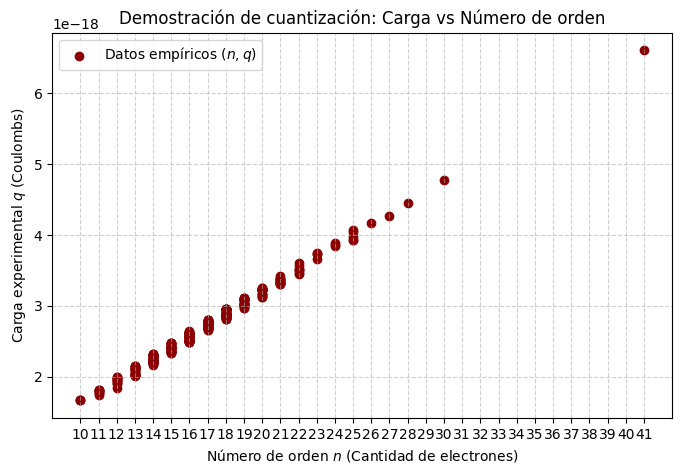

In [3]:
t = df["Tiempo [s]"]
d0 = 5 * 10**(-3)
d1 = 2 * 10**(-3)
V = 200.4
R = 1.02 * 10**(-6) / 2
g = 9.806
delta0 = 1050
delta1 = 1.225
visc = 1.78 * 10**(-5)
q = []

for i in range(len(t)):
    carga = (d0 / V) * ((4/3) * np.pi * R**3 * g * (delta0 - delta1) + (6 * np.pi * visc * R * d1 / t[i]))

    q.append(carga)

Q = np.sort(q)

q_ordenadas = Q

# 2. Configuración del histograma
e_referencia = 1.6022e-19 

# La operación vectorial divide y luego redondea al entero más cercano
n_orden = np.round(q_ordenadas / e_referencia).astype(int)

# Salida de comprobación en consola
print(" Carga q (C)  | Número de orden (n)")
print("-" * 35)
for q, n in zip(q_ordenadas, n_orden):
    print(f"  {q:.3e}   |        {n}")

# 4. Gráfico bivariante (Cargas vs. Número de orden)
plt.figure(figsize=(8, 5))

# n_orden va en el eje de las abscisas (X) y q_ordenadas en el de las ordenadas (Y)
plt.scatter(n_orden, q_ordenadas, color='darkred', marker='o', label='Datos empíricos $(n, q)$')

# Formato riguroso del gráfico
plt.title('Demostración de cuantización: Carga vs Número de orden')
plt.xlabel('Número de orden $n$ (Cantidad de electrones)')
plt.ylabel('Carga experimental $q$ (Coulombs)')

# Forzar a que las marcas del eje X sean estrictamente números enteros
plt.xticks(np.arange(min(n_orden), max(n_orden) + 1, 1.0))

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Pendiente (Carga del electrón experimental): 1.5888e-19 C
Intercepto: 2.6705e-20 C
Ecuación: q = (1.5888e-19)*n + (2.6705e-20)


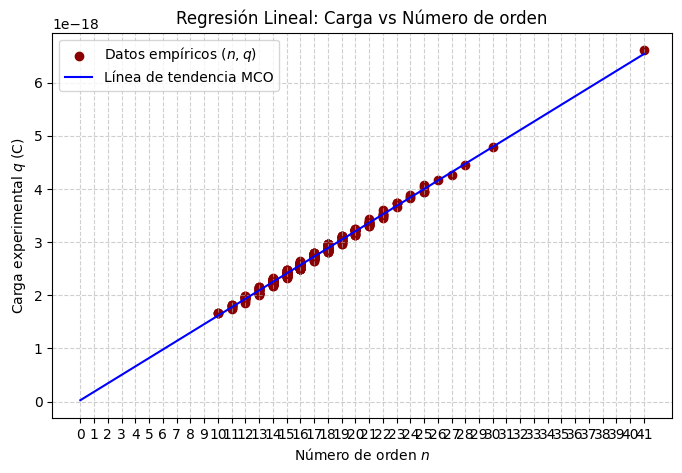

In [4]:
coeficientes = np.polyfit(n_orden, q_ordenadas, 1)

m = coeficientes[0]
b = coeficientes[1]

print(f"Pendiente (Carga del electrón experimental): {m:.4e} C")
print(f"Intercepto: {b:.4e} C")
print(f"Ecuación: q = ({m:.4e})*n + ({b:.4e})")

# Opcional: Graficar los datos y la línea de tendencia
plt.figure(figsize=(8, 5))
plt.scatter(n_orden, q_ordenadas, color='darkred', label='Datos empíricos $(n, q)$')

# Generar puntos X para la recta de regresión
x_line = np.linspace(0, max(n_orden), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='blue', linestyle='-', label='Línea de tendencia MCO')

plt.title('Regresión Lineal: Carga vs Número de orden')
plt.xlabel('Número de orden $n$')
plt.ylabel('Carga experimental $q$ (C)')
plt.xticks(np.arange(0, max(n_orden) + 1, 1.0))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [5]:
e_teorico = 1.602e-19 

# El valor experimental 'm' proviene del coeficiente[0] de tu regresión polyfit
e_experimental = m 

# Cálculo del error porcentual absoluto
error_porcentual = abs((e_teorico - e_experimental) / e_teorico) * 100

print(f"Valor teórico: {e_teorico:.4e} C")
print(f"Valor experimental: {e_experimental:.4e} C")
print(f"Error porcentual: {error_porcentual:.2f}%")

Valor teórico: 1.6020e-19 C
Valor experimental: 1.5888e-19 C
Error porcentual: 0.82%


In [6]:
for i in range(len(Q)):
    
    print(f" {Q[i]:.3e} &", end=" ")

    if (i) % 7 == 6:
        print(f" {Q[i]:.3e} \\\ \hline", end="")

    if (i+1) % 7 == 0:
        print(" ")

 1.667e-18 &  1.670e-18 &  1.673e-18 &  1.739e-18 &  1.766e-18 &  1.769e-18 &  1.791e-18 &  1.791e-18 \\ \hline 
 1.791e-18 &  1.810e-18 &  1.814e-18 &  1.817e-18 &  1.847e-18 &  1.896e-18 &  1.914e-18 &  1.914e-18 \\ \hline 
 1.929e-18 &  1.944e-18 &  1.948e-18 &  1.952e-18 &  1.971e-18 &  1.975e-18 &  1.975e-18 &  1.975e-18 \\ \hline 
 1.991e-18 &  1.991e-18 &  2.015e-18 &  2.019e-18 &  2.023e-18 &  2.023e-18 &  2.023e-18 &  2.023e-18 \\ \hline 
 2.028e-18 &  2.032e-18 &  2.036e-18 &  2.061e-18 &  2.066e-18 &  2.097e-18 &  2.106e-18 &  2.106e-18 \\ \hline 
 2.106e-18 &  2.106e-18 &  2.110e-18 &  2.119e-18 &  2.142e-18 &  2.142e-18 &  2.152e-18 &  2.152e-18 \\ \hline 
 2.156e-18 &  2.156e-18 &  2.171e-18 &  2.180e-18 &  2.190e-18 &  2.190e-18 &  2.190e-18 &  2.190e-18 \\ \hline 
 2.195e-18 &  2.205e-18 &  2.205e-18 &  2.210e-18 &  2.220e-18 &  2.225e-18 &  2.230e-18 &  2.230e-18 \\ \hline 
 2.230e-18 &  2.235e-18 &  2.235e-18 &  2.235e-18 &  2.246e-18 &  2.261e-18 &  2.267e-18 &  2.26

<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
C:\Users\andy\AppData\Local\Temp\ipykernel_3652\217299172.py:6: SyntaxWarning: invalid escape sequence '\ '
  print(f" {Q[i]:.3e} \\\ \hline", end="")
